In [17]:
import torch
import time
import copy
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version : {torch.__version__}")
print(f"Running on : {device.upper()}")

#--------Defining variables--------------

data_dir = './data'
batch_size = 32
num_classes = 102
num_epochs = 20
patience = 5
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

PyTorch version : 2.10.0+cu128
Running on : CUDA


In [3]:
# 1. TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [8]:
# Load Dataset

train_data = datasets.Flowers102(root = data_dir, split='train', download=True, transform=train_transform)
val_data = datasets.Flowers102(root = data_dir , split='val', download = True, transform=train_transform)
test_data = datasets.Flowers102(root = data_dir , split='test', download = True, transform=train_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train : {len(train_data):,} images")
print(f"  Val   : {len(val_data):,} images")
print(f"  Test  : {len(test_data):,} images")

  Train : 1,020 images
  Val   : 1,020 images
  Test  : 6,149 images


In [12]:
# Classification Head
def build_head(in_features):
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes),
    )

In [22]:
# Training Loop

def train_model(model, optimizer, label):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {"train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = None
    patience_counter = 0
    best_epoch = 1
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):

        model.train()
        train_correct, train_total = 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()               # clear old gradients
            outputs = model(images)             # forward pass
            loss = criterion(outputs, labels)# compute loss
            loss.backward()                     # backpropagation

            # Gradient clipping: if gradients get very large
            # (exploding), clip them to max_norm=1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()                    # update weights

            preds          = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

        train_acc = 100 * train_correct / train_total

        # ── Validation phase ──────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if(epoch) % 5 == 0:
          print(f"  [{label:20s}] Epoch {epoch:02d}/{num_epochs} | Train: {train_acc:5.1f}% | Val: {val_acc:5.1f}%")

        # ── Save best model ─────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch
        else:
            patience_counter += 1

        # ── Early stopping ────────────────────────
        if patience_counter >= patience:
            print(f"  [{label}] Early stopping triggered at epoch {epoch}.")
            break

    total_time = time.time() - start_time
    model.load_state_dict(best_weights)
    return model, history, total_time, best_epoch

In [23]:
# Feature Extraction

model_fe = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model_fe.parameters():
    param.requires_grad = False
model_fe.fc = build_head(model_fe.fc.in_features)
optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)

model_fe, hist_fe, time_fe, epoch_fe = train_model(model_fe, optimizer_fe, label="Feature Extraction")

print(f"\n  Best Val Acc : {max(hist_fe['val_acc']):.1f}%")
print(f"  Best Epoch  : {epoch_fe}")
print(f"  Total Time  : {time_fe:.0f}s")

  [Feature Extraction  ] Epoch 05/20 | Train:  98.8% | Val:  85.6%
  [Feature Extraction  ] Epoch 10/20 | Train:  99.9% | Val:  86.8%
  [Feature Extraction  ] Epoch 15/20 | Train: 100.0% | Val:  85.3%
  [Feature Extraction] Early stopping triggered at epoch 15.

  Best Val Acc : 86.8%
  Best Epoch  : 10
  Total Time  : 298s


In [24]:
# Partial Fine- Tuning

model_pft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

frozen_layers = [model_pft.conv1, model_pft.bn1,model_pft.layer1, model_pft.layer2]

for layer in frozen_layers:
    for param in layer.parameters():
        param.requires_grad = False

model_pft.fc = build_head(model_pft.fc.in_features)
optimizer_pft = optim.Adam([
    {'params': model_pft.layer3.parameters(), 'lr': 1e-5},
    {'params': model_pft.layer4.parameters(), 'lr': 1e-5},
    {'params': model_pft.fc.parameters(), 'lr': 1e-3},
])

model_pft, hist_pft, time_pft, epoch_pft = train_model(model_pft, optimizer_pft, label="Partial Fine-Tuning")

print(f"\n  Best Val Acc : {max(hist_pft['val_acc']):.1f}%")
print(f"  Best Epoch  : {epoch_pft}")
print(f"  Total Time  : {time_pft:.0f}s")

  [Partial Fine-Tuning ] Epoch 05/20 | Train:  99.4% | Val:  87.5%
  [Partial Fine-Tuning ] Epoch 10/20 | Train: 100.0% | Val:  89.5%
  [Partial Fine-Tuning ] Epoch 15/20 | Train: 100.0% | Val:  89.5%
  [Partial Fine-Tuning] Early stopping triggered at epoch 16.

  Best Val Acc : 90.5%
  Best Epoch  : 11
  Total Time  : 353s


In [25]:
# Full Fine- Tuning

model_fft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_fft.fc = build_head(model_fft.fc.in_features)

optimizer_fft = optim.Adam([
    {'params': model_fft.layer1.parameters(), 'lr': 1e-6},  # barely touch
    {'params': model_fft.layer2.parameters(), 'lr': 1e-6},  # barely touch
    {'params': model_fft.layer3.parameters(), 'lr': 1e-5},  # gently adapt
    {'params': model_fft.layer4.parameters(), 'lr': 1e-5},  # gently adapt
    {'params': model_fft.fc.parameters(), 'lr': 1e-3},      # learn fast
])

model_fft, hist_fft, time_fft, epoch_fft = train_model(model_fft, optimizer_fft, label="Full Fine-Tuning")

print(f"\nBest Val Acc : {max(hist_fft['val_acc']):.1f}%")
print(f"Best Epoch  : {epoch_fft}")
print(f"Total Time  : {time_fft:.0f}s")

  [Full Fine-Tuning    ] Epoch 05/20 | Train:  99.2% | Val:  86.8%
  [Full Fine-Tuning    ] Epoch 10/20 | Train: 100.0% | Val:  88.9%
  [Full Fine-Tuning    ] Epoch 15/20 | Train:  99.8% | Val:  90.2%
  [Full Fine-Tuning    ] Epoch 20/20 | Train: 100.0% | Val:  89.4%

  Best Val Acc : 90.7%
  Best Epoch  : 18
  Total Time  : 468s


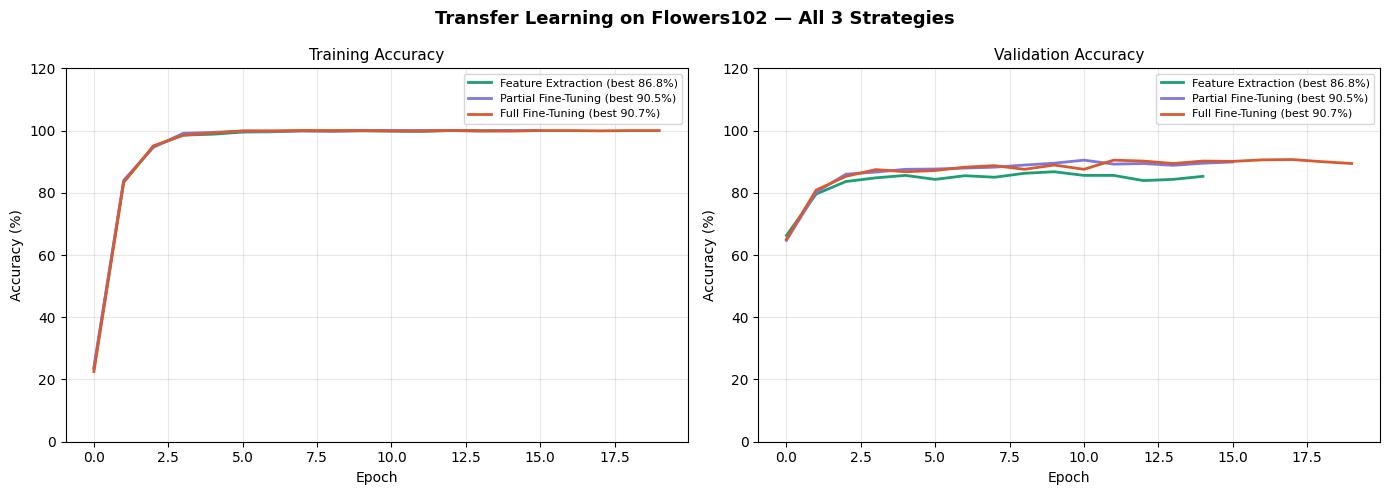

In [28]:
# Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transfer Learning on Flowers102 — All 3 Strategies",fontsize=13, fontweight='bold')

# Colors for each strategy
C_FE  = "#1D9E75"   # green  → Feature Extraction
C_PFT = "#7F77DD"   # purple → Partial Fine-Tuning
C_FFT = "#D85A30"   # orange → Full Fine-Tuning

for ax, key, title in [
    (ax1, "train_acc", "Training Accuracy"),
    (ax2, "val_acc", "Validation Accuracy"),
]:
    ax.plot(hist_fe[key],  color=C_FE, linewidth=2, label=f"Feature Extraction (best {max(hist_fe['val_acc']):.1f}%)")
    ax.plot(hist_pft[key], color=C_PFT, linewidth=2, label=f"Partial Fine-Tuning (best {max(hist_pft['val_acc']):.1f}%)")
    ax.plot(hist_fft[key], color=C_FFT, linewidth=2, label=f"Full Fine-Tuning (best {max(hist_fft['val_acc']):.1f}%)")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 120)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Evaluate Best Model on Test

scores = {
    "Feature Extraction" : (model_fe,  max(hist_fe['val_acc'])),
    "Partial Fine-Tuning": (model_pft, max(hist_pft['val_acc'])),
    "Full Fine-Tuning" : (model_fft, max(hist_fft['val_acc'])),
}
best_name = max(scores, key=lambda k: scores[k][1])
best_model = scores[best_name][0]

print(f"\nBest strategy by val acc: {best_name}")
print("Evaluating on held-out TEST set")

best_model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        preds = best_model(images).argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy ({best_name}): {test_acc:.2f}%")


Best strategy by val acc: Full Fine-Tuning
Evaluating on held-out TEST set
Test Accuracy (Full Fine-Tuning): 88.66%
